**1.** Round just for display (doesn't change the real stored number, just how it prints):
```
print("Determinant:", round(det, 4))
print("Inverse:\n", np.round(inv, 4))
```
np.round(inv, 4) rounds every number in the matrix to 4 decimal places — clean output, real math underneath is unchanged.

**4.** Tell NumPy to always print cleaner, for the rest of your session:
```
np.set_printoptions(precision=4, suppress=True)
```

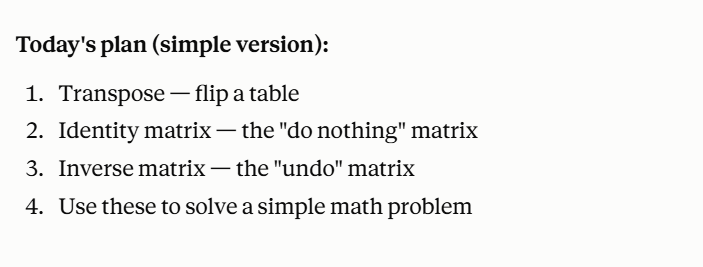

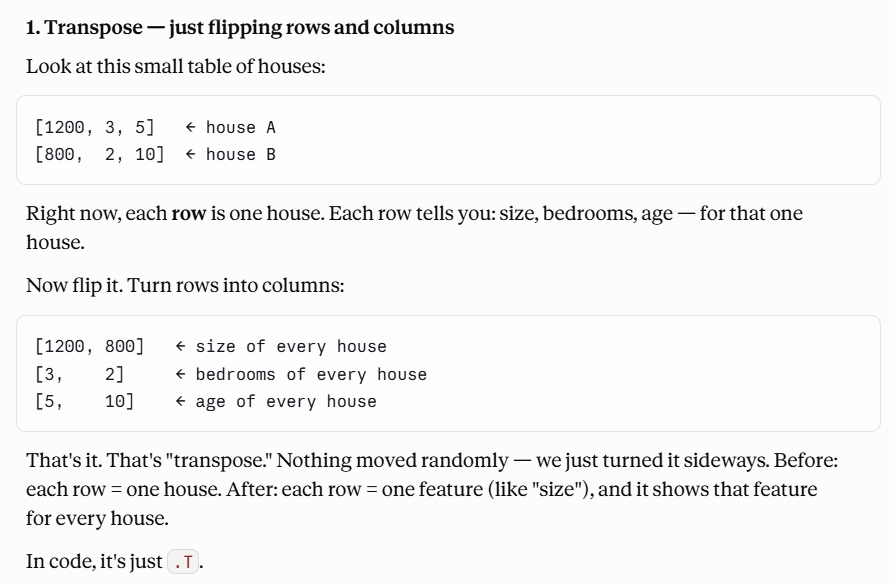

In [2]:
from cmath import isclose

import numpy as np
A = np.array([[1200, 3],
              [800,  2],
              [2000, 4],
              [950,  2],
              [550, 6]])
print(A @ A.T)
print("\n", A.T @ A)
print("\n", A.T)

[[1440009  960006 2400012 1140006  660018]
 [ 960006  640004 1600008  760004  440012]
 [2400012 1600008 4000016 1900008 1100024]
 [1140006  760004 1900008  902504  522512]
 [ 660018  440012 1100024  522512  302536]]

 [[7285000   18400]
 [  18400      69]]

 [[1200  800 2000  950  550]
 [   3    2    4    2    6]]


In [3]:
import numpy as np
X = np.array([1200, 3, 5])
I = [[1, 0, 0],
     [0, 1, 0],
     [0, 0, 1]]

print(X @ I)

[1200    3    5]


**2. Identity matrix — the "do nothing" matrix**

Think about regular numbers first. What number can you multiply by anything, and get the same thing back?

7 × 1 = 7. The number 1 does nothing when you multiply by it.

Matrices have their own version of "1" — a matrix that does nothing when you multiply by it. It's called the identity matrix. It looks like this:
```
[1, 0]
[0, 1]
```
1's going diagonally, 0's everywhere else.

Remember basic algebra: 5 × x = 20. To find x, you divide both sides by 5. Dividing by 5 is really just "multiplying by the thing that undoes 5" — because 5 × (1/5) = 1, the do-nothing number.

Matrices work the same way. If we have a matrix equation like A × x = b and want to find x, we need something that undoes A — we call it A⁻¹ (A-inverse). And here's the key fact:
```
A × A⁻¹ = I   (the do-nothing matrix)
```
So the identity matrix's whole job is to be the finish line. When you multiply a matrix by its own inverse, you should land exactly on the identity matrix — that's how you know the inverse is correct.

In plain words: **identity matrix = "1" for matrices. Inverse matrix = "1/5" for matrices — the thing that undoes multiplication.**

**3. Inverse matrix — the "undo" button**

For a small 2×2 matrix, there's a simple recipe to find its inverse. Let's use this matrix:
```
A = [4, 7]
    [2, 6]
```
Step 1 is always the same: calculate one number called the determinant. Simple rule:

Multiply the two corner numbers going one diagonal way, then subtract the two corner numbers going the other diagonal way.

For our matrix: top-left is 4, bottom-right is 6 → multiply those: 4 × 6. Top-right is 7, bottom-left is 2 → multiply those: 7 × 2. Then subtract.

24 − 14 = 10. That's the determinant.

Here's the simple rule: **if the determinant is 0, the matrix has NO inverse.** There's no "undo" for it — it's stuck, like trying to divide by zero. If the determinant is anything other than 0 (like our 10), the matrix CAN be undone, and we can build the inverse.

**Step 2 — the easy recipe to build the inverse**, once you have the determinant:

Swap the two diagonal numbers (top-left and bottom-right switch places)
Flip the sign (make positive→negative) on the other two numbers
Divide everything by the determinant
Let's do it on our matrix:
```
A = [4, 7]
    [2, 6]
```
**Step 1 — swap the diagonal (4 and 6 switch):**
```
[6, 7]
[2, 4]
```
**Step 2 — flip sign on the other two (7 and 2 become negative):**
```
[6, -7]
[-2, 4]
```
**Step 3 — divide every number by the determinant (10):**
```
A⁻¹ = [0.6, -0.7]
      [-0.2, 0.4]
```
That's the whole inverse, built by hand.

**Quick recap of what we've built today, in plain words:**

**Transpose** = flip a table sideways (rows become columns)

**Identity matrix** = the matrix version of "1" — does nothing when you multiply by it

**Inverse matrix** = the matrix version of "1/5" — undoes a matrix

**Determinant** = one number that tells you if a matrix CAN be undone (zero = no, anything else = yes)

In [4]:
# Example 1

import numpy as np

A = np.array([[4, 7],
              [2, 6]])

b = np.array([40, 26])

# 1. Find the determinant of A
#det = np.linalg.det(A)
det = np.round(np.linalg.det(A))

# 2. Find the inverse of A
inv = np.linalg.inv(A)

# 3. Solve for x, y using A_inverse @ b
result = inv @ b

# 4. Print all three
print("Determinant of A:", det)
print("Inverse of A:", inv)
print("Solve for x, y:", result)

Determinant of A: 10.0
Inverse of A: [[ 0.6 -0.7]
 [-0.2  0.4]]
Solve for x, y: [5.8 2.4]


In [5]:
# This does the same job — solves A × x = b — but it's faster and more accurate

x_y = np.linalg.solve(A, b)
print(x_y)

[5.8 2.4]


In [6]:
# Example 2

import numpy as np
np.set_printoptions(precision=4, suppress=True)

A = np.array([
    [5, 1, 0, 2, 0],
    [1, 4, 1, 0, 1],
    [0, 1, 6, 1, 0],
    [2, 0, 1, 5, 1],
    [0, 1, 0, 1, 4]
])

b = np.array([10, 12, 14, 16, 10])

det = np.linalg.det(A)
inv = np.linalg.inv(A)
result = inv @ b

#OR

solution = np.linalg.solve(A, b)

print("Determinant:", det)
print("\n Inverse:\n", inv) # Round values to the 4 decimals
print("\n Solution [x1,x2,x3,x4,x5]:", solution)

Determinant: 1456.0

 Inverse:
 [[ 0.2679 -0.0893  0.0357 -0.125   0.0536]
 [-0.0893  0.3118 -0.0632  0.0673 -0.0948]
 [ 0.0357 -0.0632  0.1868 -0.0577  0.0302]
 [-0.125   0.0673 -0.0577  0.2788 -0.0865]
 [ 0.0536 -0.0948  0.0302 -0.0865  0.2953]]

 Solution [x1,x2,x3,x4,x5]: [0.6429 2.0934 1.5934 2.3462 1.3901]


#### Homework 1

Transpose

B = [9, 1, 4]
    [2, 7, 6]

What shape is B? What shape will B.T be? Write out B.T by hand (just flip rows into columns), then confirm with B.T in NumPy.

In [7]:
B = np.array([[9, 1, 4],
    [2, 7, 6]])

print(np.shape(B))
print("\n", B.T)

(2, 3)

 [[9 2]
 [1 7]
 [4 6]]


#### Homework 2

Determinant & Inverse (new 2×2, do this one by hand)
```
C = [3, 5]
    [1, 4]
```
Find det(C) by hand (diagonal multiply, subtract)
Is it invertible? (is det zero or not?)

Build C⁻¹ by hand using the 3-step recipe (swap diagonal, flip sign on the other two, divide by determinant)

Then verify with np.linalg.det(C) and np.linalg.inv(C) — do your hand numbers match?

In [8]:
C = np.array([[3, 5],
    [1, 4]])

print("Determinant:", np.linalg.det(C))
print("\n Inverse:\n", np.linalg.inv(C))

Determinant: 7.000000000000001

 Inverse:
 [[ 0.5714 -0.7143]
 [-0.1429  0.4286]]


#### Homework 3

Solve a system (use code, this one's bigger)

Solve this for x and y:
```
3x + 5y = 23
x + 4y = 18
```
1. Turn it into A @ [x,y] = b form (what are A and b?)
2. Solve using np.linalg.solve(A, b)
3. Plug your x, y answer back into both original equations by hand to check they're both true

In [9]:
#1
A = np.array([[3,5],
     [1,4]])

b = [23, 18]

#2
print(np.linalg.solve(A, b))

#3 (By hand)
# (3 * 0.2857) + (5 * 4.4286) = 23
# (0.2857) + (4 * 4.4286) = 18

[0.2857 4.4286]
